In [1]:
# Cell 1: Import check
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

print("OpenCV version:", cv2.__version__)
print("All imports successful!")

OpenCV version: 4.13.0
All imports successful!


In [2]:
# Cell 2: Point to your dataset and explore it
# IMPORTANT: Change this path to where your unzipped ASL dataset actually is
dataset_path = r'C:\Users\USER\Desktop\Projects\ASL_Dataset\asl_alphabet_train\asl_alphabet_train'

# If your folder is somewhere else, find it in File Explorer, right-click → Properties → Location
# Example alternatives:
# dataset_path = r'C:\Users\USER\Downloads\asl-alphabet\asl_alphabet_train'
# dataset_path = r'D:\Datasets\asl_alphabet_train'

# List the letter folders (should show A, B, C, ..., Z)
letters = sorted(os.listdir(dataset_path))
print("Found letters:", letters)
print("Total number of classes:", len(letters))

# Show count of images per letter (first 10 letters as example)
print("\nImage counts:")
for letter in letters[:10]:
    count = len(os.listdir(os.path.join(dataset_path, letter)))
    print(f"  {letter}: {count} images")

Found letters: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Total number of classes: 29

Image counts:
  A: 3000 images
  B: 3000 images
  C: 3000 images
  D: 3000 images
  E: 3000 images
  F: 3000 images
  G: 3000 images
  H: 3000 images
  I: 3000 images
  J: 3000 images


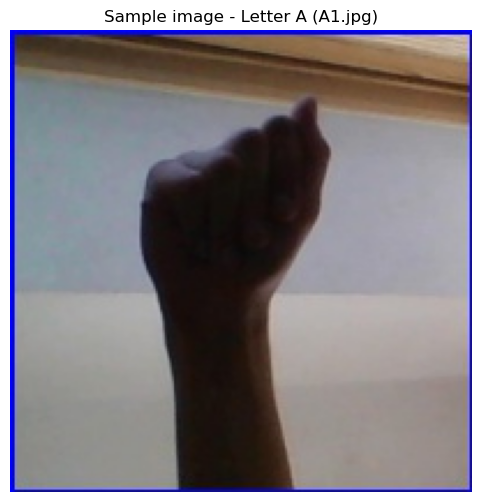

Image shape (height, width, channels): (200, 200, 3)


In [3]:
# Cell 3: Display a sample image from letter 'A'
sample_letter = 'A'

if sample_letter in letters:
    # Get the first image in the 'A' folder
    a_folder = os.path.join(dataset_path, sample_letter)
    first_image_name = os.listdir(a_folder)[0]  # take the first file
    sample_path = os.path.join(a_folder, first_image_name)

    # Load and display
    img = cv2.imread(sample_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # fix colors
        plt.figure(figsize=(6, 6))
        plt.imshow(img_rgb)
        plt.title(f"Sample image - Letter {sample_letter} ({first_image_name})")
        plt.axis('off')
        plt.show()
        
        print("Image shape (height, width, channels):", img.shape)
    else:
        print("Error: Could not load the image. Check if the file exists.")
else:
    print(f"Letter '{sample_letter}' not found. Check your letters list above.")

In [4]:
import os

dataset_path = r'C:\Users\USER\Desktop\Projects\ASL_Dataset\asl_alphabet_train\asl_alphabet_train'
  # keep your working path here

# Get all class folders
classes = sorted(os.listdir(dataset_path))

print("Total classes found:", len(classes))
print("Classes:", classes)

# Count images per class
print("\nImage count per class:")
image_counts = {}
total_images = 0

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        image_counts[cls] = count
        total_images += count
        print(f"{cls:2s}: {count:5d} images")

print(f"\nTotal images in dataset: {total_images}")

Total classes found: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

Image count per class:
A :  3000 images
B :  3000 images
C :  3000 images
D :  3000 images
E :  3000 images
F :  3000 images
G :  3000 images
H :  3000 images
I :  3000 images
J :  3000 images
K :  3000 images
L :  3000 images
M :  3000 images
N :  3000 images
O :  3000 images
P :  3000 images
Q :  3000 images
R :  3000 images
S :  3000 images
T :  3000 images
U :  3000 images
V :  3000 images
W :  3000 images
X :  3000 images
Y :  3000 images
Z :  3000 images
del:  3000 images
nothing:  3000 images
space:  3000 images

Total images in dataset: 87000


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# ========================
#  CONFIGURATION
# ========================
dataset_path = r'C:\Users\USER\Desktop\Projects\ASL_Dataset\asl_alphabet_train\asl_alphabet_train'  # your working path

IMG_SIZE = 64          # 64×64 is fast and good enough for start
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2

# We want only A-Z (26 classes)
TARGET_CLASSES = [c for c in sorted(os.listdir(dataset_path)) if c.isupper() and len(c) == 1]
print("Training on classes:", TARGET_CLASSES)
print("Number of target classes:", len(TARGET_CLASSES))

# ========================
#  DATA GENERATOR with augmentation
# ========================
datagen = ImageDataGenerator(
    rescale=1./255,               # normalize 0-1
    validation_split=VALIDATION_SPLIT,
    
    # Augmentation - very important for skin tones, lighting, angles
    rotation_range=15,            # slight rotations
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.7, 1.3],  # helps with different lighting / skin tones
    horizontal_flip=True,
    fill_mode='nearest'
)

# Training generator
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',       # hand shape > color
    classes=TARGET_CLASSES,       # only A-Z
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    classes=TARGET_CLASSES,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Print class mapping (important!)
print("\nClass indices (letter → number):")
for letter, idx in train_generator.class_indices.items():
    print(f"{letter:2s} → {idx}")

Training on classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of target classes: 26
Found 62400 images belonging to 26 classes.
Found 15600 images belonging to 26 classes.

Class indices (letter → number):
A  → 0
B  → 1
C  → 2
D  → 3
E  → 4
F  → 5
G  → 6
H  → 7
I  → 8
J  → 9
K  → 10
L  → 11
M  → 12
N  → 13
O  → 14
P  → 15
Q  → 16
R  → 17
S  → 18
T  → 19
U  → 20
V  → 21
W  → 22
X  → 23
Y  → 24
Z  → 25


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# ========================
#  BUILD THE CNN MODEL
# ========================
IMG_SIZE = 64
NUM_CLASSES = 26

model = Sequential([
    # Input: 64×64×1 (grayscale)
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    # Flatten and dense layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),          # Helps prevent overfitting
    Dense(NUM_CLASSES, activation='softmax')   # 26 output classes
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 6, 6, 128)        0

In [15]:
# ========================
#  TRAIN THE MODEL
# ========================
EPOCHS = 15          # Start with 15; we can increase later
STEPS_PER_EPOCH = train_generator.samples // BATCH_SIZE
VALIDATION_STEPS = val_generator.samples // BATCH_SIZE

history = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    verbose=1
)

# Save the model so you don't lose it
model.save('asl_alphabet_model_v1.h5')
print("Model saved as 'asl_alphabet_model_v1.h5'")

Epoch 1/15
975/975 [==============================] - 4252s 4s/step - loss: 2.1717 - accuracy: 0.3267 - val_loss: 1.9255 - val_accuracy: 0.4120
Epoch 2/15
975/975 [==============================] - 411s 422ms/step - loss: 1.1752 - accuracy: 0.6137 - val_loss: 1.6132 - val_accuracy: 0.4948
Epoch 3/15
975/975 [==============================] - 416s 426ms/step - loss: 0.8334 - accuracy: 0.7200 - val_loss: 1.4106 - val_accuracy: 0.5666
Epoch 4/15
975/975 [==============================] - 548s 562ms/step - loss: 0.6479 - accuracy: 0.7817 - val_loss: 1.3489 - val_accuracy: 0.6146
Epoch 5/15
975/975 [==============================] - 597s 612ms/step - loss: 0.5328 - accuracy: 0.8209 - val_loss: 1.2868 - val_accuracy: 0.6456
Epoch 6/15
975/975 [==============================] - 604s 620ms/step - loss: 0.4520 - accuracy: 0.8480 - val_loss: 1.1987 - val_accuracy: 0.6543
Epoch 7/15
975/975 [==============================] - 603s 618ms/step - loss: 0.3900 - accuracy: 0.8693 - val_loss: 1.1196 - v

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# This will save the best model so far after every epoch
checkpoint = ModelCheckpoint(
    'asl_model_best.h5',          # file name
    monitor='val_accuracy',       # save when validation accuracy improves
    save_best_only=True,          # only save the best one
    mode='max',
    verbose=1
)

# You can also save after every epoch (even if not better)
checkpoint_all = ModelCheckpoint(
    'asl_model_epoch_{epoch:02d}.h5',
    save_best_only=False,
    verbose=1
)

# Now train with callbacks
history = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    callbacks=[checkpoint, checkpoint_all],   # ← add this
    verbose=1
)

In [7]:
import os

print("Saved .h5 files in current folder:")
for file in os.listdir('.'):
    if file.endswith('.h5'):
        print("→", file)
        

Saved .h5 files in current folder:
→ asl_alphabet_model_v1.h5
→ asl_model_best.h5
→ asl_model_epoch_01.h5
→ asl_model_epoch_02.h5
→ asl_model_epoch_03.h5
→ asl_model_epoch_04.h5
→ asl_model_epoch_05.h5
→ asl_model_epoch_06.h5
→ asl_model_epoch_07.h5
→ asl_model_epoch_08.h5
→ asl_model_epoch_09.h5
→ asl_model_epoch_10.h5
→ asl_model_epoch_11.h5


In [7]:
from tensorflow.keras.models import load_model

# Load the best saved model
model = load_model('asl_model_best.h5')

print("Best model loaded successfully!")
model.summary()  # shows the architecture to confirm

Best model loaded successfully!
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoo

In [9]:
# Evaluate on validation data
loss, accuracy = model.evaluate(val_generator, verbose=1)

print(f"Validation loss: {loss:.4f}")
print(f"Validation accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

244/244 [==============================] - 105s 427ms/step - loss: 1.0310 - accuracy: 0.7617
Validation loss: 1.0310
Validation accuracy: 0.7617 (76.17%)


In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'asl_model_best_v2.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

checkpoint_all = ModelCheckpoint(
    'asl_model_epoch_{epoch:02d}.h5',
    save_best_only=False,
    verbose=1
)

# Continue training
history_new = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 64,
    epochs=20,               # change to how many you want (e.g. 10)
    initial_epoch=11,        # start counting from 12 (since you have epoch 11)
    validation_data=val_generator,
    validation_steps=val_generator.samples // 64,
    callbacks=[checkpoint, checkpoint_all],
    verbose=1
)

model.save('asl_model_after_more_epochs.h5')

Epoch 12/20
975/975 [==============================] - ETA: 0s - loss: 0.1256 - accuracy: 0.9588
Epoch 12: val_accuracy improved from -inf to 0.75585, saving model to asl_model_best_v2.h5

Epoch 12: saving model to asl_model_epoch_12.h5
975/975 [==============================] - 651s 667ms/step - loss: 0.1256 - accuracy: 0.9588 - val_loss: 1.2324 - val_accuracy: 0.7559
Epoch 13/20
975/975 [==============================] - ETA: 0s - loss: 0.1280 - accuracy: 0.9584
Epoch 13: val_accuracy improved from 0.75585 to 0.76100, saving model to asl_model_best_v2.h5

Epoch 13: saving model to asl_model_epoch_13.h5
975/975 [==============================] - 606s 621ms/step - loss: 0.1280 - accuracy: 0.9584 - val_loss: 1.1870 - val_accuracy: 0.7610
Epoch 14/20
975/975 [==============================] - ETA: 0s - loss: 0.1255 - accuracy: 0.9593
Epoch 14: val_accuracy improved from 0.76100 to 0.77128, saving model to asl_model_best_v2.h5

Epoch 14: saving model to asl_model_epoch_14.h5
975/975 [====

In [4]:
import cv2
import numpy as np

# If you haven't loaded the model yet, do it now
# model = load_model('asl_model_best_v2.h5')  # or whichever has the best val acc

class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 
               'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 
               'U', 'V', 'W', 'X', 'Y', 'Z']

cap = cv2.VideoCapture(0)  # your webcam

print("Webcam test started. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame (stream end?). Exiting...")
        break

    # Preprocess exactly like training
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (64, 64))
    normalized = resized / 255.0
    input_img = normalized.reshape(1, 64, 64, 1)

    # Predict
    prediction = model.predict(input_img, verbose=0)
    predicted_idx = np.argmax(prediction)
    confidence = prediction[0][predicted_idx] * 100
    letter = class_names[predicted_idx]

    # Draw on screen
    text = f"{letter} ({confidence:.1f}%)"
    cv2.putText(frame, text, (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 
                2, (0, 255, 0) if confidence > 70 else (0, 0, 255), 3)

    cv2.imshow('ASL Recognizer - Press q to quit', frame)

    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Webcam closed.")

Webcam test started. Press 'q' to quit.


NameError: name 'model' is not defined

In [5]:
from tensorflow.keras.models import load_model

# Load your best or latest saved model
# Choose one of these based on what you have (from your list)
model = load_model('asl_model_best_v2.h5')          # ← best validation accuracy
# or
# model = load_model('asl_model_epoch_14.h5')       # epoch 14 had highest val acc ~77%
# or
# model = load_model('asl_alphabet_model_v1.h5')

print("Model loaded successfully!")
print("Number of output classes:", model.output_shape[-1])  # should be 26


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\anaconda3\envs\sign_translator\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\envs\sign_translator\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\envs\sign_translator\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\envs\sign_translator\lib\site-packages\traitlets\config\application.py", line 10

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\anaconda3\envs\sign_translator\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\envs\sign_translator\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\envs\sign_translator\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\envs\sign_translator\lib\site-packages\traitlets\config\application.py", line 10

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

ImportError: numpy.core.umath failed to import

TypeError: Unable to convert function return value to a Python type! The signature was
	() -> handle

In [6]:
import cv2
import numpy as np

# === Safety check ===
try:
    model  # If this line errors → model not defined
    print("Model is already loaded → good!")
except NameError:
    print("ERROR: Model is not loaded yet!")
    print("→ First run the model loading cell above")
    # Stop here if model not loaded
    raise

# Class names (must match your training order)
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
               'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
               'U', 'V', 'W', 'X', 'Y', 'Z']

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam. Check if it's connected/allowed.")
else:
    print("Webcam opened! Show your hand signs. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break

    # Preprocess
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (64, 64))
    normalized = resized / 255.0
    input_img = normalized.reshape(1, 64, 64, 1)

    # Predict
    prediction = model.predict(input_img, verbose=0)
    predicted_idx = np.argmax(prediction)
    confidence = prediction[0][predicted_idx] * 100
    letter = class_names[predicted_idx]

    # Draw result
    text = f"{letter} ({confidence:.1f}%)"
    color = (0, 255, 0) if confidence > 70 else (0, 0, 255)
    cv2.putText(frame, text, (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 2, color, 3)

    cv2.imshow('ASL Recognizer - Press q to quit', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Webcam closed.")

ERROR: Model is not loaded yet!
→ First run the model loading cell above


NameError: name 'model' is not defined

In [7]:
from tensorflow.keras.models import load_model

# Choose one of your saved files — I recommend the best one
# Option 1: the best validation accuracy
model = load_model('asl_model_best_v2.h5')

# Option 2: if you want to use the last epoch instead
# model = load_model('asl_model_epoch_20.h5')

print("Model loaded successfully!")
print("Number of classes (should be 26):", model.output_shape[-1])

TypeError: Unable to convert function return value to a Python type! The signature was
	() -> handle

In [8]:
from tensorflow.keras.models import load_model

model = load_model('asl_model_best_v2.h5')
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import cv2
import numpy as np

# Make sure model is loaded (from the cell above)
try:
    model
    print("Model is ready")
except NameError:
    print("ERROR: Model is not loaded yet! Run the loading cell first.")
    raise

# Class names — must match your 26 letters exactly
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
               'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
               'U', 'V', 'W', 'X', 'Y', 'Z']

# Start webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam. Make sure it's connected and not used by another app.")
else:
    print("Webcam started! Show your hand signs clearly. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to capture frame")
        break

    # Preprocess the frame (same as training)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (64, 64))
    normalized = resized / 255.0
    input_img = normalized.reshape(1, 64, 64, 1)

    # Predict
    prediction = model.predict(input_img, verbose=0)
    predicted_idx = np.argmax(prediction)
    confidence = prediction[0][predicted_idx] * 100
    letter = class_names[predicted_idx]

    # Show result on screen
    text = f"{letter} ({confidence:.1f}%)"
    color = (0, 255, 0) if confidence > 70 else (0, 0, 255)
    cv2.putText(frame, text, (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 2, color, 3)

    # Display the frame
    cv2.imshow('ASL Letter Recognizer - Press q to quit', frame)

    # Press 'q' to stop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Cleanup
cap.release()
cv2.destroyAllWindows()
print("Webcam closed.")

Model is ready
Webcam started! Show your hand signs clearly. Press 'q' to quit.


In [8]:
from tensorflow.keras.models import load_model

# Load the best checkpoint
model = load_model('asl_model_best_v2.h5')   # or whichever had ~77% val acc

print("Best model loaded")
model.summary()

Best model loaded
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 6

In [9]:
loss, acc = model.evaluate(val_generator, verbose=1)
print(f"Current validation accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Validation loss: {loss:.4f}")

244/244 [==============================] - 99s 403ms/step - loss: 1.1497 - accuracy: 0.7727
Current validation accuracy: 0.7727 (77.27%)
Validation loss: 1.1497


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Your dataset path (make sure it's correct)
dataset_path = r'C:\Users\USER\Desktop\Projects\ASL_Dataset\asl_alphabet_train\asl_alphabet_train'

IMG_SIZE = 64
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2

TARGET_CLASSES = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

# Stronger augmentation - this is the key change
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT,
    
    # Increased variation for better generalization
    rotation_range=30,               # more rotation
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.25,
    zoom_range=[0.75, 1.25],         # wider zoom
    brightness_range=[0.5, 1.5],     # stronger brightness change → helps with skin tones & lighting
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest',
    cval=0                           # fill with black when shifting
)

# Re-create generators
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    classes=TARGET_CLASSES,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    classes=TARGET_CLASSES,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("New generators ready with stronger augmentation!")
print(f"Train: {train_generator.samples} images")
print(f"Val:   {val_generator.samples} images")

Found 62400 images belonging to 26 classes.
Found 15600 images belonging to 26 classes.
New generators ready with stronger augmentation!
Train: 62400 images
Val:   15600 images


In [14]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # halve the learning rate
    patience=4,          # wait 4 epochs of no improvement
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'asl_model_improved_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


In [15]:
# Train with new augmentation + callbacks
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=15,                     # adjust as needed
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=[reduce_lr, checkpoint],
    verbose=1
)

# Save final model
model.save('asl_model_after_improvement.h5')
print("Training finished. Final model saved!")

Epoch 1/15
975/975 [==============================] - ETA: 0s - loss: 1.1442 - accuracy: 0.6625
Epoch 1: val_accuracy improved from -inf to 0.58764, saving model to asl_model_improved_best.h5
975/975 [==============================] - 792s 811ms/step - loss: 1.1442 - accuracy: 0.6625 - val_loss: 1.4065 - val_accuracy: 0.5876 - lr: 0.0010
Epoch 2/15
975/975 [==============================] - ETA: 0s - loss: 0.9051 - accuracy: 0.7193
Epoch 2: val_accuracy improved from 0.58764 to 0.60385, saving model to asl_model_improved_best.h5
975/975 [==============================] - 721s 739ms/step - loss: 0.9051 - accuracy: 0.7193 - val_loss: 1.3134 - val_accuracy: 0.6038 - lr: 0.0010
Epoch 3/15
975/975 [==============================] - ETA: 0s - loss: 0.8186 - accuracy: 0.7425
Epoch 3: val_accuracy improved from 0.60385 to 0.62867, saving model to asl_model_improved_best.h5
975/975 [==============================] - 719s 737ms/step - loss: 0.8186 - accuracy: 0.7425 - val_loss: 1.2550 - val_accu

In [16]:
loss, acc = model.evaluate(val_generator, verbose=1)
print(f"New validation accuracy after training: {acc:.4f} ({acc*100:.2f}%)")
print(f"New validation loss: {loss:.4f}")

244/244 [==============================] - 61s 249ms/step - loss: 1.0204 - accuracy: 0.6987
New validation accuracy after training: 0.6987 (69.87%)
New validation loss: 1.0204


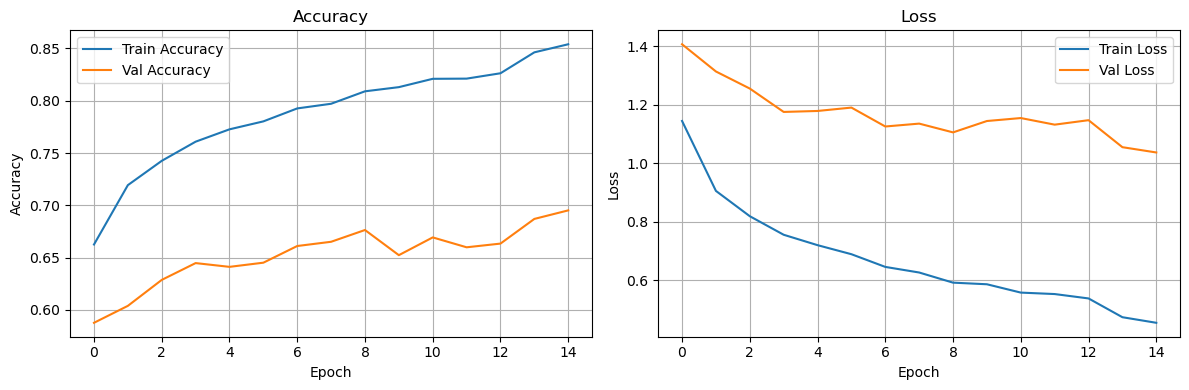

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Make sure model and generators are loaded
# If not, re-run the generator cell and model loading cell first

from tensorflow.keras.optimizers import Adam

# Lower the learning rate a bit for stability
model.compile(
    optimizer=Adam(learning_rate=0.0005),  # lower than default 0.001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled with lower learning rate")

Model recompiled with lower learning rate


244/244 [==============================] - 62s 251ms/step - loss: 1.0346 - accuracy: 0.6957
Latest validation accuracy: 0.6957 (69.57%)
Latest validation loss: 1.0346


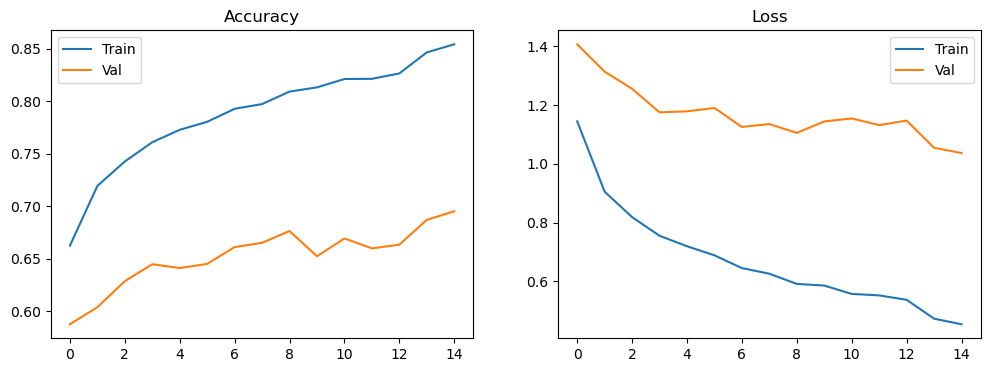

In [19]:
loss, acc = model.evaluate(val_generator, verbose=1)
print(f"Latest validation accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Latest validation loss: {loss:.4f}")

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.show()